# Titanic EDA — Who Survived, and Why?

This notebook explores the classic Titanic passenger manifest to answer one
question: **which passengers were more likely to survive, and what factors
were associated with that?**

It is an **exploratory data analysis (EDA) only** notebook — no predictive
model is built here. The goal is to show clear, reproducible thinking about
a messy real-world dataset, not to optimize a benchmark.

**Structure**
1. Load data
2. Initial inspection
3. Cleaning (with reasoning for each decision)
4. Exploratory analysis
5. Findings (~150 words)

**Data source:** the canonical Titanic passenger list, as distributed by the
[pandas project](https://github.com/pandas-dev/pandas/blob/master/doc/data/titanic.csv)
(891 passengers, 12 original columns). A copy is stored at `data/titanic.csv`
in this repo so the notebook runs offline and reproducibly.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)


In [2]:
%matplotlib inline


## 1. Load data

Single cell, relative path from the repo root — no absolute/local paths.

In [3]:
df = pd.read_csv("data/titanic.csv")
print(f"Shape: {df.shape}")
df.head(3)


Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


## 2. Initial inspection

Before touching anything, let's understand what we're working with: column
types, missing values, and basic summary statistics.

In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [5]:
missing = df.isnull().sum()
missing[missing > 0].sort_values(ascending=False)


Cabin       687
Age         177
Embarked      2
dtype: int64

Two columns stand out immediately:
- **`Age`** is missing for 177 of 891 passengers (~20%).
- **`Cabin`** is missing for 687 of 891 passengers (~77%) — too sparse to use as-is.
- **`Embarked`** is missing for just 2 passengers.

This matches what the dataset is known for: it's small enough to fit in
memory but messy enough to force real decisions about missing data and
mixed types.

## 3. Cleaning

Each step below includes a comment on **why** that decision was made, not
just what it does.

In [6]:
# Cabin is 77% missing -- too sparse to impute meaningfully or use directly.
# Rather than dropping the signal entirely, we keep a binary flag: passengers
# who HAD a recorded cabin were disproportionately 1st/2nd class, so
# "has_cabin" likely still carries information even though the exact cabin
# number would not.
df["has_cabin"] = df["Cabin"].notna().astype(int)
df = df.drop(columns=["Cabin"])

# Embarked is missing for only 2 rows -- filling with the mode (Southampton,
# by far the most common port) has negligible effect on the analysis and
# avoids dropping two otherwise-complete rows.
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])
port_map = {"S": "Southampton", "C": "Cherbourg", "Q": "Queenstown"}
df["embark_town"] = df["Embarked"].map(port_map)
df = df.drop(columns=["Embarked"])

# Age is missing for ~20% of passengers -- too many to drop without losing
# meaningful sample size. A single global median would ignore the fact that
# age differs systematically by class and sex (e.g. 3rd class had more young
# male laborers). We impute using the median Age within each (Pclass, Sex)
# group, which is a better-informed guess than a single overall median.
df["Age"] = df.groupby(["Pclass", "Sex"])["Age"].transform(lambda s: s.fillna(s.median()))

# PassengerId, Name, and Ticket are unique identifiers / free text with no
# direct analytical value for this EDA (Name could be mined for titles, but
# that's a feature-engineering step we flag for "next steps" rather than do
# here, to keep this EDA-only as scoped).
df = df.drop(columns=["PassengerId", "Name", "Ticket"])

# Pclass and Sex are categorical in nature even though Pclass is stored as
# an integer -- casting makes that explicit and avoids accidentally treating
# class as a continuous number in later steps.
df["Pclass"] = df["Pclass"].astype("category")
df["Sex"] = df["Sex"].astype("category")

# A human-readable label is easier to read in plots than 0/1.
df["Survived_label"] = df["Survived"].map({0: "No", 1: "Yes"})

# Family size is a natural derived feature: SibSp (siblings/spouses) +
# Parch (parents/children) + the passenger themself.
df["family_size"] = df["SibSp"] + df["Parch"] + 1
df["is_alone"] = (df["family_size"] == 1).astype(int)

print("Missing values after cleaning:")
print(df.isnull().sum().sum(), "total missing cells remain")
df.head(3)


Missing values after cleaning:
0 total missing cells remain


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,has_cabin,embark_town,Survived_label,family_size,is_alone
0,0,3,male,22.0,1,0,7.2500,0,Southampton,No,2,0
1,1,1,female,38.0,1,0,71.2833,1,Cherbourg,Yes,2,0
2,1,3,female,26.0,0,0,7.9250,0,Southampton,Yes,1,1


## 4. Exploratory analysis

We look at survival broken down by the factors most often cited as
influencing who got a seat in a lifeboat: sex, class, age, fare, family
size, and port of embarkation.

In [7]:
print(f"Overall survival rate: {df['Survived'].mean():.1%}")


Overall survival rate: 38.3%


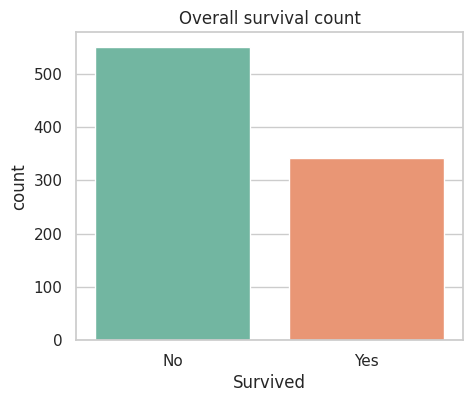

In [8]:
fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(x="Survived_label", data=df, ax=ax, hue="Survived_label", palette="Set2", legend=False)
ax.set_title("Overall survival count")
ax.set_xlabel("Survived")
plt.show()


Sex
female    0.738854
male      0.188908
Name: Survived, dtype: float64


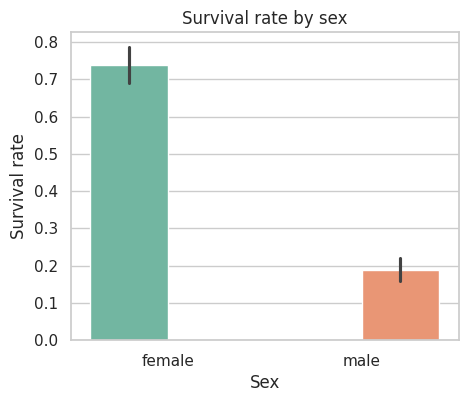

In [9]:
fig, ax = plt.subplots(figsize=(5, 4))
sns.barplot(x="Sex", y="Survived", data=df, ax=ax, hue="Sex", palette="Set2", legend=False)
ax.set_title("Survival rate by sex")
ax.set_ylabel("Survival rate")
plt.show()
print(df.groupby("Sex", observed=True)["Survived"].mean())


Pclass
1    0.629630
2    0.472826
3    0.240326
Name: Survived, dtype: float64


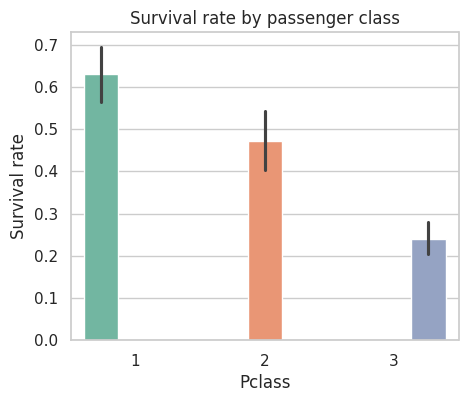

In [10]:
fig, ax = plt.subplots(figsize=(5, 4))
sns.barplot(x="Pclass", y="Survived", data=df, ax=ax, hue="Pclass", palette="Set2", legend=False)
ax.set_title("Survival rate by passenger class")
ax.set_ylabel("Survival rate")
plt.show()
print(df.groupby("Pclass", observed=True)["Survived"].mean())


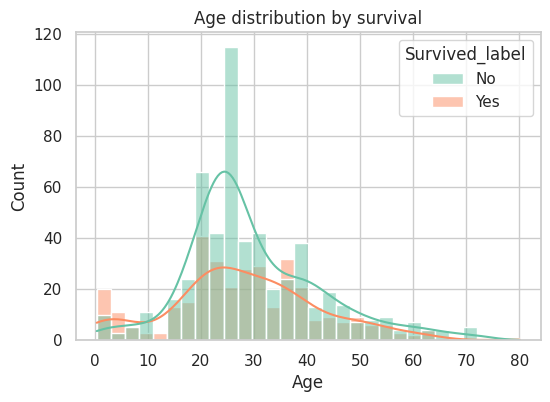

In [11]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.histplot(data=df, x="Age", hue="Survived_label", kde=True, bins=30, ax=ax, palette="Set2")
ax.set_title("Age distribution by survival")
plt.show()


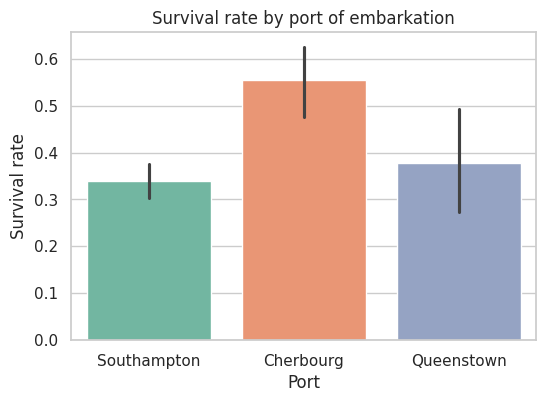

In [12]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(x="embark_town", y="Survived", data=df, ax=ax, hue="embark_town", palette="Set2", legend=False)
ax.set_title("Survival rate by port of embarkation")
ax.set_ylabel("Survival rate")
ax.set_xlabel("Port")
plt.show()


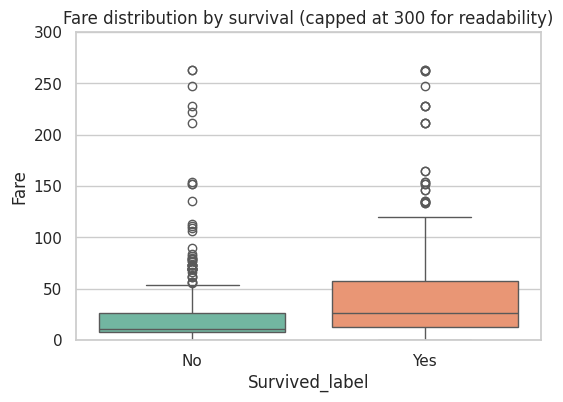

In [13]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(x="Survived_label", y="Fare", data=df, ax=ax, hue="Survived_label", palette="Set2", legend=False)
ax.set_ylim(0, 300)
ax.set_title("Fare distribution by survival (capped at 300 for readability)")
plt.show()


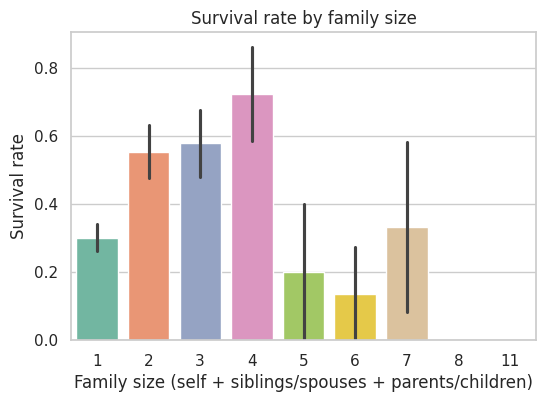

In [14]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(x="family_size", y="Survived", data=df, ax=ax, hue="family_size", palette="Set2", legend=False)
ax.set_title("Survival rate by family size")
ax.set_ylabel("Survival rate")
ax.set_xlabel("Family size (self + siblings/spouses + parents/children)")
plt.show()


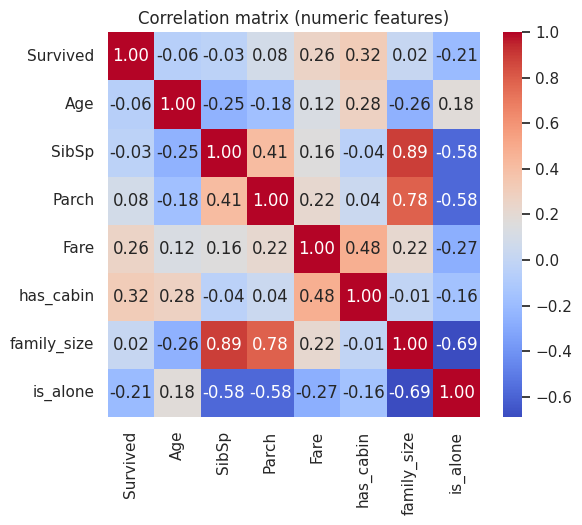

In [15]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", ax=ax)
ax.set_title("Correlation matrix (numeric features)")
plt.show()


## 5. Findings

**Who survived, and why:** survival was driven far more by who a passenger
*was* than by chance. **Sex was the strongest factor** — women survived at
roughly 74%, men at about 19%, consistent with a "women and children
first" evacuation. **Class mattered almost as much**: 1st class survived
at ~63%, versus ~47% (2nd) and ~24% (3rd), reflecting cabin location and
lifeboat access; fare tracked the same pattern. **Children had a modest
edge** over young adults, while **large families (5+) fared worse** than
small families or solo travelers, likely from struggling to stay together
during evacuation. Port of embarkation showed a smaller effect, mostly
because it correlates with class.

**With more time**, next steps: engineer a "title" feature from names
(Mr/Mrs/Miss/Master) as a finer age/status proxy, test interaction effects
(class × sex), and train a baseline logistic regression to quantify these
effects jointly rather than one at a time.